# Predicting Student Academic Outcomes at the End of Semester 1
## A Comparative Evaluation of Classification Models

## 1. Data Loading and Initial Inspection

In [90]:
import pandas as pd

In [91]:
import matplotlib.pyplot as plt

In [92]:
df = pd.read_csv("data.csv", sep=";")

In [93]:
df.columns = df.columns.str.strip()

In [94]:
df.head()

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


In [95]:
df.shape

(4424, 37)

In [96]:
df.columns

Index(['Marital status', 'Application mode', 'Application order', 'Course',
       'Daytime/evening attendance', 'Previous qualification',
       'Previous qualification (grade)', 'Nacionality',
       'Mother's qualification', 'Father's qualification',
       'Mother's occupation', 'Father's occupation', 'Admission grade',
       'Displaced', 'Educational special needs', 'Debtor',
       'Tuition fees up to date', 'Gender', 'Scholarship holder',
       'Age at enrollment', 'International',
       'Curricular units 1st sem (credited)',
       'Curricular units 1st sem (enrolled)',
       'Curricular units 1st sem (evaluations)',
       'Curricular units 1st sem (approved)',
       'Curricular units 1st sem (grade)',
       'Curricular units 1st sem (without evaluations)',
       'Curricular units 2nd sem (credited)',
       'Curricular units 2nd sem (enrolled)',
       'Curricular units 2nd sem (evaluations)',
       'Curricular units 2nd sem (approved)',
       'Curricular units 2nd s

In [97]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

### 1.1 Target Variable

In [98]:
df['Target'].unique()

<ArrowStringArray>
['Dropout', 'Graduate', 'Enrolled']
Length: 3, dtype: str

In [99]:
df['Target'].value_counts()

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

## 2. Exploratory Data Analysis

### 2.1 Data Quality Checks

In [100]:
df.isnull().sum()

Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship holder                                0
Age at enrol

In [101]:
df.duplicated().sum()

np.int64(0)

In [102]:
missing_counts = df.isnull().sum()

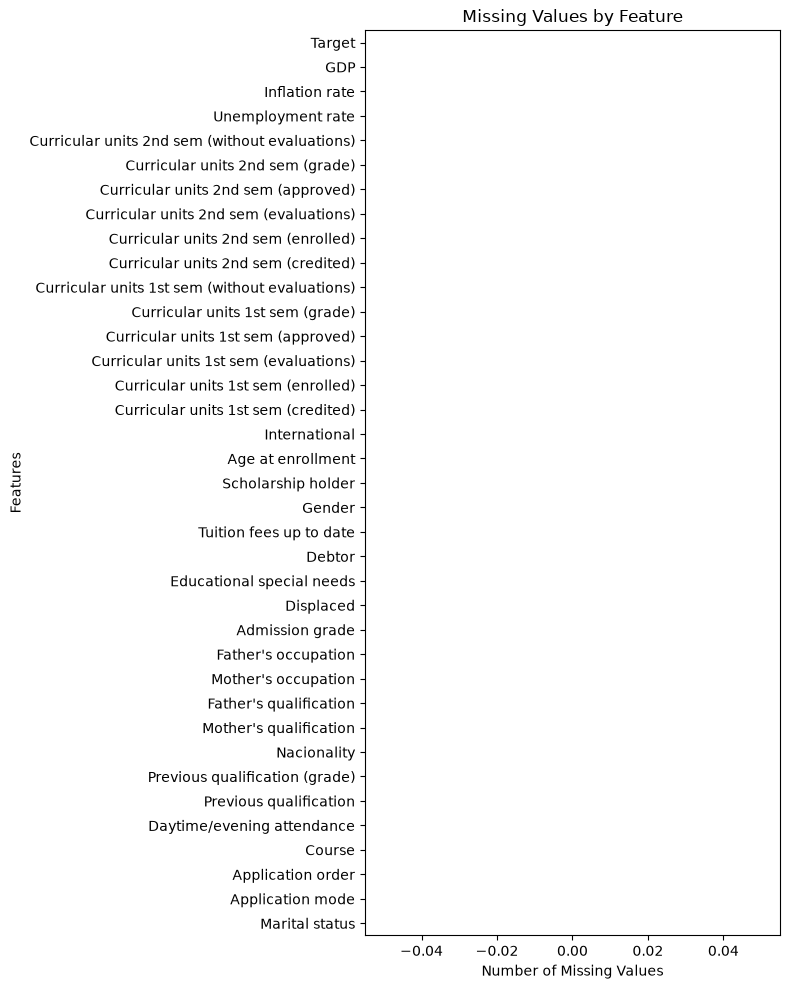

In [103]:
missing_counts.plot(kind='barh', figsize=(8, 10))
plt.title('Missing Values by Feature')
plt.xlabel('Number of Missing Values')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

### 2.2 Target Distribution

In [104]:
target_counts = df['Target'].value_counts()
target_counts

Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64

In [105]:
target_percentages = df['Target'].value_counts(normalize=True) * 100
target_percentages

Target
Graduate    49.932188
Dropout     32.120253
Enrolled    17.947559
Name: proportion, dtype: float64

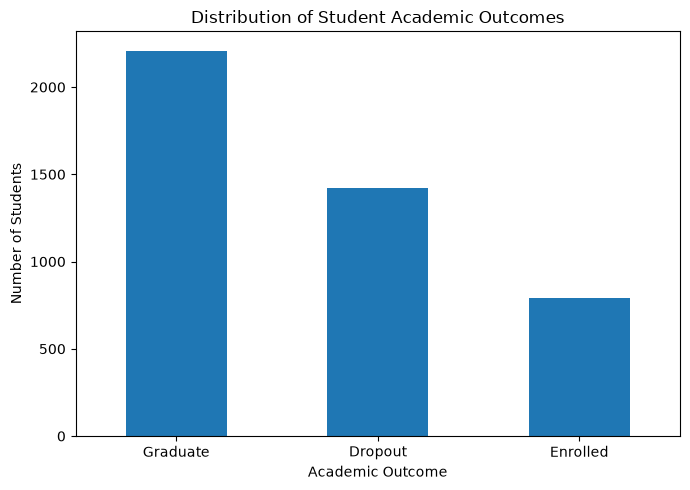

In [106]:
target_counts.plot(kind='bar', figsize=(7, 5))
plt.title('Distribution of Student Academic Outcomes')
plt.xlabel('Academic Outcome')
plt.ylabel('Number of Students')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### 2.3 Age at Enrollment

In [107]:
df['Age at enrollment'].describe()

count    4424.000000
mean       23.265145
std         7.587816
min        17.000000
25%        19.000000
50%        20.000000
75%        25.000000
max        70.000000
Name: Age at enrollment, dtype: float64

In [108]:
df['Age at enrollment'].median()

np.float64(20.0)

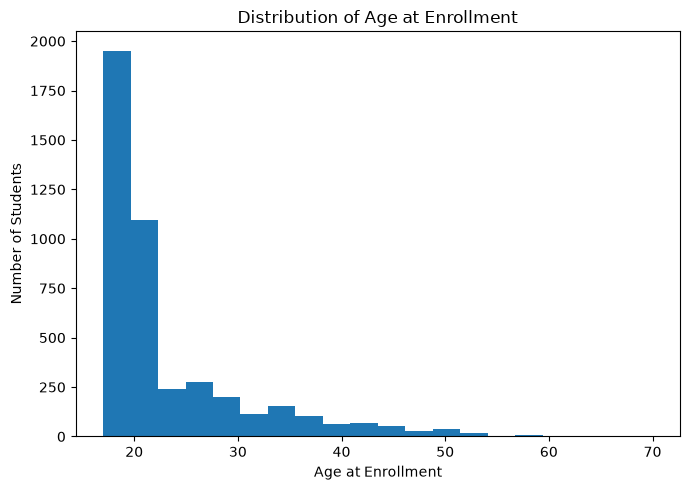

In [109]:
df['Age at enrollment'].plot(kind='hist', bins=20, figsize=(7, 5))
plt.title('Distribution of Age at Enrollment')
plt.xlabel('Age at Enrollment')
plt.ylabel('Number of Students')
plt.tight_layout()
plt.show()

### 2.4 Semester 1 Grade and Academic Outcome

In [110]:
df['Curricular units 1st sem (grade)'].describe()

count    4424.000000
mean       10.640822
std         4.843663
min         0.000000
25%        11.000000
50%        12.285714
75%        13.400000
max        18.875000
Name: Curricular units 1st sem (grade), dtype: float64

In [111]:
df['Curricular units 1st sem (grade)'].median()

np.float64(12.285714285714286)

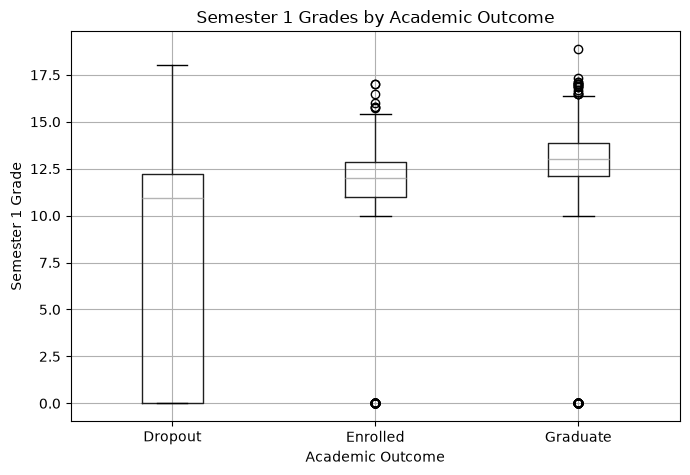

In [112]:
df.boxplot(
    column='Curricular units 1st sem (grade)',
    by='Target',
    figsize=(7, 5)
)

plt.title('Semester 1 Grades by Academic Outcome')
plt.suptitle('')
plt.xlabel('Academic Outcome')
plt.ylabel('Semester 1 Grade')
plt.tight_layout()
plt.show()

### 2.5 Semester 1 Approved Units and Academic Outcome

In [113]:
df['Curricular units 1st sem (approved)'].describe()

count    4424.000000
mean        4.706600
std         3.094238
min         0.000000
25%         3.000000
50%         5.000000
75%         6.000000
max        26.000000
Name: Curricular units 1st sem (approved), dtype: float64

In [114]:
df['Curricular units 1st sem (approved)'].median()

np.float64(5.0)

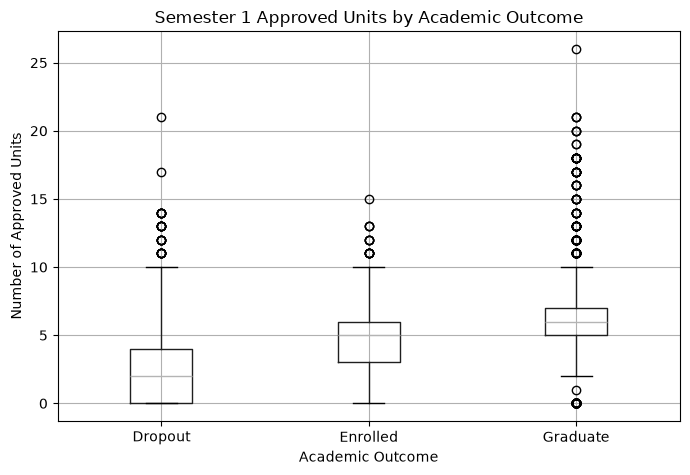

In [115]:
df.boxplot(
    column='Curricular units 1st sem (approved)',
    by='Target',
    figsize=(7, 5)
)

plt.title('Semester 1 Approved Units by Academic Outcome')
plt.suptitle('')
plt.xlabel('Academic Outcome')
plt.ylabel('Number of Approved Units')
plt.tight_layout()
plt.show()

## 3. Data Preprocessing and Feature Engineering

### 3.1 Temporal Leakage Prevention

In [116]:
semester2_cols = [col for col in df.columns if '2nd sem' in col]
semester2_cols

['Curricular units 2nd sem (credited)',
 'Curricular units 2nd sem (enrolled)',
 'Curricular units 2nd sem (evaluations)',
 'Curricular units 2nd sem (approved)',
 'Curricular units 2nd sem (grade)',
 'Curricular units 2nd sem (without evaluations)']

In [117]:
X = df.drop(columns=semester2_cols + ['Target'])
y = df['Target']

In [118]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Semester 2 columns remaining:", [col for col in X.columns if '2nd sem' in col])

X shape: (4424, 30)
y shape: (4424,)
Semester 2 columns remaining: []


### 3.2 Training and Testing Data

In [119]:
from sklearn.model_selection import train_test_split

In [120]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [121]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (3539, 30)
X_test: (885, 30)
y_train: (3539,)
y_test: (885,)


In [122]:
print("Training target proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting target proportions:")
print(y_test.value_counts(normalize=True))

Training target proportions:
Target
Graduate    0.499294
Dropout     0.321277
Enrolled    0.179429
Name: proportion, dtype: float64

Testing target proportions:
Target
Graduate    0.499435
Dropout     0.320904
Enrolled    0.179661
Name: proportion, dtype: float64


### 3.3 Feature Types

In [123]:
categorical_features = [
    'Marital status',
    'Application mode',
    'Course',
    'Daytime/evening attendance',
    'Previous qualification',
    'Nacionality',
    "Mother's qualification",
    "Father's qualification",
    "Mother's occupation",
    "Father's occupation",
    'Displaced',
    'Educational special needs',
    'Debtor',
    'Tuition fees up to date',
    'Gender',
    'Scholarship holder',
    'International'
]

In [124]:
numerical_features = [
    'Application order',
    'Previous qualification (grade)',
    'Admission grade',
    'Age at enrollment',
    'Curricular units 1st sem (credited)',
    'Curricular units 1st sem (enrolled)',
    'Curricular units 1st sem (evaluations)',
    'Curricular units 1st sem (approved)',
    'Curricular units 1st sem (grade)',
    'Curricular units 1st sem (without evaluations)',
    'Unemployment rate',
    'Inflation rate',
    'GDP'
]

In [125]:
print("Categorical features:", len(categorical_features))
print("Numerical/ordered features:", len(numerical_features))
print("Total features:", len(categorical_features) + len(numerical_features))

Categorical features: 17
Numerical/ordered features: 13
Total features: 30


In [126]:
defined_features = categorical_features + numerical_features

print("Features missing from lists:",
      [col for col in X.columns if col not in defined_features])

print("Extra features in lists:",
      [col for col in defined_features if col not in X.columns])

Features missing from lists: []
Extra features in lists: []


### 3.4 Preprocessing Strategies

In [127]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [128]:
preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numerical_features)
    ]
)

In [129]:
preprocessor_scaled = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

In [130]:
print("Unscaled preprocessing:")
print(preprocessor_unscaled)

print("\nScaled preprocessing:")
print(preprocessor_scaled)

Unscaled preprocessing:
ColumnTransformer(transformers=[('cat', OneHotEncoder(handle_unknown='ignore'),
                                 ['Marital status', 'Application mode',
                                  'Course', 'Daytime/evening attendance',
                                  'Previous qualification', 'Nacionality',
                                  "Mother's qualification",
                                  "Father's qualification",
                                  "Mother's occupation", "Father's occupation",
                                  'Displaced', 'Educational special needs',
                                  'Debtor', 'Tuition fees up to date', 'Ge...
                                ('num', 'passthrough',
                                 ['Application order',
                                  'Previous qualification (grade)',
                                  'Admission grade', 'Age at enrollment',
                                  'Curricular units 1st sem (credited

## 4. Model Development

### 4.1 Logistic Regression: Preprocessing Comparison

In [131]:
import warnings
from sklearn.exceptions import ConvergenceWarning

In [132]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

In [133]:
warnings.filterwarnings("ignore", category=ConvergenceWarning)

In [134]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [135]:
logreg_unscaled = Pipeline([
    ('preprocessor', preprocessor_unscaled),
    ('model', LogisticRegression(max_iter=1000))
])

unscaled_scores = cross_val_score(
    logreg_unscaled,
    X_train,
    y_train,
    cv=cv,
    scoring='f1_macro'
)

print("Unscaled fold scores:", unscaled_scores)
print("Mean Macro F1:", unscaled_scores.mean())

Unscaled fold scores: [0.6779663  0.66561958 0.66272264 0.65576373 0.63746795]
Mean Macro F1: 0.6599080407341034


In [136]:
logreg_scaled = Pipeline([
    ('preprocessor', preprocessor_scaled),
    ('model', LogisticRegression(max_iter=1000))
])

scaled_scores = cross_val_score(
    logreg_scaled,
    X_train,
    y_train,
    cv=cv,
    scoring='f1_macro'
)

print("Scaled fold scores:", scaled_scores)
print("Mean Macro F1:", scaled_scores.mean())

Scaled fold scores: [0.68374767 0.6682396  0.64658979 0.6622512  0.63632386]
Mean Macro F1: 0.6594304256458599


### 4.2 Effect of Standard Scaling

In [137]:
preprocessing_results = pd.Series({
    'Unscaled': unscaled_scores.mean(),
    'StandardScaler': scaled_scores.mean()
})

preprocessing_results

Unscaled          0.659908
StandardScaler    0.659430
dtype: float64

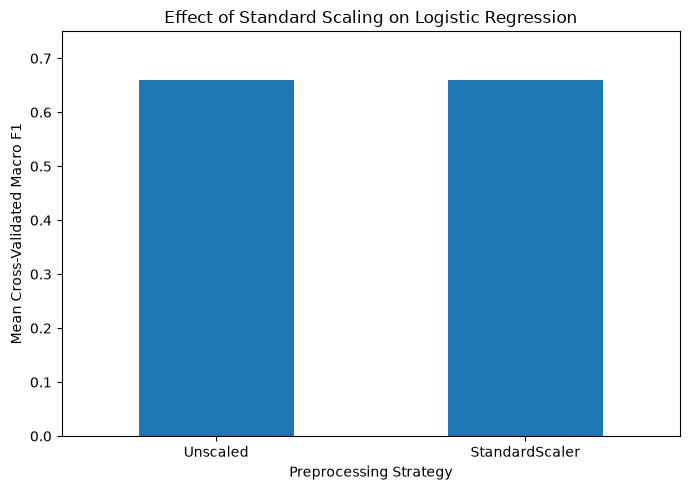

In [138]:
preprocessing_results.plot(kind='bar', figsize=(7, 5))

plt.title('Effect of Standard Scaling on Logistic Regression')
plt.xlabel('Preprocessing Strategy')
plt.ylabel('Mean Cross-Validated Macro F1')
plt.xticks(rotation=0)
plt.ylim(0, 0.75)
plt.tight_layout()
plt.show()

- Scaling produced almost no change in Macro F1.
- The unscaled model produced convergence warnings.
- StandardScaler was therefore retained for Logistic Regression because it improved numerical stability rather than predictive performance.

### 4.3 Logistic Regression Hyperparameter Tuning

In [139]:
from sklearn.model_selection import GridSearchCV

In [140]:
logreg_param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100]
}

In [141]:
logreg_grid = GridSearchCV(
    estimator=logreg_scaled,
    param_grid=logreg_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)

logreg_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of informa

In [142]:
print("Best parameters:", logreg_grid.best_params_)
print("Best CV Macro F1:", logreg_grid.best_score_)

Best parameters: {'model__C': 1}
Best CV Macro F1: 0.6594304256458599


### 4.4 Logistic Regression Tuning Results

In [143]:
logreg_tuning_results = pd.DataFrame(logreg_grid.cv_results_)

logreg_tuning_results[
    ['param_model__C', 'mean_test_score']
]

,param_model__C,mean_test_score
0,0.01,0.593428
1,0.10,0.653846
2,1.00,0.659430
3,10.00,0.658757
4,100.00,0.653720


In [144]:
c_values = logreg_tuning_results['param_model__C'].astype(float)
c_scores = logreg_tuning_results['mean_test_score']

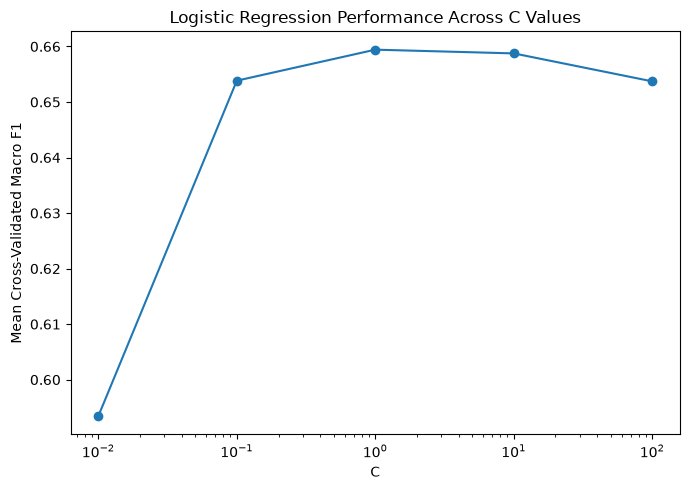

In [145]:
plt.figure(figsize=(7, 5))

plt.plot(c_values, c_scores, marker='o')
plt.xscale('log')

plt.title('Logistic Regression Performance Across C Values')
plt.xlabel('C')
plt.ylabel('Mean Cross-Validated Macro F1')
plt.tight_layout()
plt.show()

- C = 1 produced the highest cross-validated Macro F1.
- C = 0.01 performed noticeably worse, indicating that very strong regularization reduced performance.
- Increasing C beyond 1 did not improve performance.
- The tuned value C = 1 is also the default Logistic Regression setting, so tuning did not improve the baseline model.

## 5. Random Forest Classification

### 5.1 Random Forest Baseline

In [146]:
from sklearn.ensemble import RandomForestClassifier

In [147]:
rf_pipeline = Pipeline([
    ('preprocessor', preprocessor_unscaled),
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

In [148]:
rf_scores = cross_val_score(
    rf_pipeline,
    X_train,
    y_train,
    cv=cv,
    scoring='f1_macro'
)

print("Random Forest fold scores:", rf_scores)
print("Mean Macro F1:", rf_scores.mean())

Random Forest fold scores: [0.64996377 0.65358214 0.63473966 0.62022408 0.63065817]
Mean Macro F1: 0.637833562695061


- Random Forest achieved a mean cross-validated Macro F1 of approximately 0.638.
- Logistic Regression achieved approximately 0.659.
- Therefore, Logistic Regression had the stronger baseline cross-validation performance.
- Hyperparameter tuning is still required before making the final model comparison.

### 5.2 Random Forest Hyperparameter Tuning

In [149]:
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}

In [150]:
rf_grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring='f1_macro',
    cv=cv,
    n_jobs=-1
)

In [151]:
rf_grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1_macro'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable a

In [152]:
print("Best parameters:", rf_grid.best_params_)
print("Best CV Macro F1:", rf_grid.best_score_)

Best parameters: {'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 100}
Best CV Macro F1: 0.637833562695061


### 5.3 Random Forest Tuning Results

In [153]:
rf_tuning_results = pd.DataFrame(rf_grid.cv_results_)

rf_tuning_results[
    [
        'param_model__max_depth',
        'param_model__min_samples_split',
        'param_model__n_estimators',
        'mean_test_score'
    ]
]

,param_model__max_depth,param_model__min_samples_split,param_model__n_estimators,mean_test_score
0,None,2,100,0.637834
1,None,2,200,0.633478
2,None,5,100,0.625630
3,None,5,200,0.629246
4,10,2,100,0.565303
5,10,2,200,0.561609
6,10,5,100,0.564200
7,10,5,200,0.559067
8,20,2,100,0.619601
9,20,2,200,0.626285


In [154]:
rf_depth_results = (
    rf_tuning_results
    .groupby('param_model__max_depth', dropna=False)['mean_test_score']
    .mean()
)

rf_depth_results

param_model__max_depth
NaN     0.631547
10.0    0.562545
20.0    0.622095
Name: mean_test_score, dtype: float64

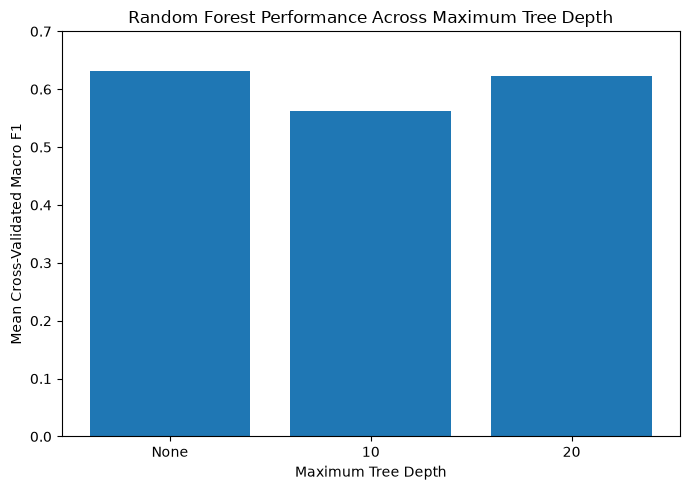

In [155]:
depth_labels = [
    'None' if pd.isna(depth) else str(int(depth))
    for depth in rf_depth_results.index
]

plt.figure(figsize=(7, 5))
plt.bar(depth_labels, rf_depth_results.values)

plt.title('Random Forest Performance Across Maximum Tree Depth')
plt.xlabel('Maximum Tree Depth')
plt.ylabel('Mean Cross-Validated Macro F1')
plt.ylim(0, 0.7)
plt.tight_layout()
plt.show()

- The unrestricted depth setting had the highest average Macro F1.
- A maximum depth of 10 produced the lowest average performance.
- The grid search selected max_depth=None, min_samples_split=2 and n_estimators=100.
- The selected configuration achieved Macro F1 ≈ 0.638 and did not improve on the Random Forest baseline.
- The depth values in the graph are averages across the other tested hyperparameter combinations, so the graph should not be interpreted as showing the isolated effect of max_depth.

## 6. Final Model Evaluation

### 6.1 Test-Set Predictions

In [156]:
best_logreg = logreg_grid.best_estimator_
best_rf = rf_grid.best_estimator_

In [157]:
logreg_pred = best_logreg.predict(X_test)
rf_pred = best_rf.predict(X_test)

In [158]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [159]:
logreg_metrics = {
    'Accuracy': accuracy_score(y_test, logreg_pred),
    'Precision': precision_score(y_test, logreg_pred, average='macro'),
    'Recall': recall_score(y_test, logreg_pred, average='macro'),
    'Macro F1': f1_score(y_test, logreg_pred, average='macro')
}

rf_metrics = {
    'Accuracy': accuracy_score(y_test, rf_pred),
    'Precision': precision_score(y_test, rf_pred, average='macro'),
    'Recall': recall_score(y_test, rf_pred, average='macro'),
    'Macro F1': f1_score(y_test, rf_pred, average='macro')
}

print("Logistic Regression:")
print(logreg_metrics)

print("\nRandom Forest:")
print(rf_metrics)

Logistic Regression:
{'Accuracy': 0.7480225988700565, 'Precision': 0.6864878452566261, 'Recall': 0.6601732061549792, 'Macro F1': 0.6671396327627805}

Random Forest:
{'Accuracy': 0.7242937853107345, 'Precision': 0.6419855411943889, 'Recall': 0.6051573916973864, 'Macro F1': 0.5993410644294478}


### 6.2 Test-Set Performance Comparison

In [160]:
results = pd.DataFrame({
    'Logistic Regression': logreg_metrics,
    'Random Forest': rf_metrics
}).T

results

,Accuracy,Precision,Recall,Macro F1
Logistic Regression,0.748023,0.686488,0.660173,0.667140
Random Forest,0.724294,0.641986,0.605157,0.599341


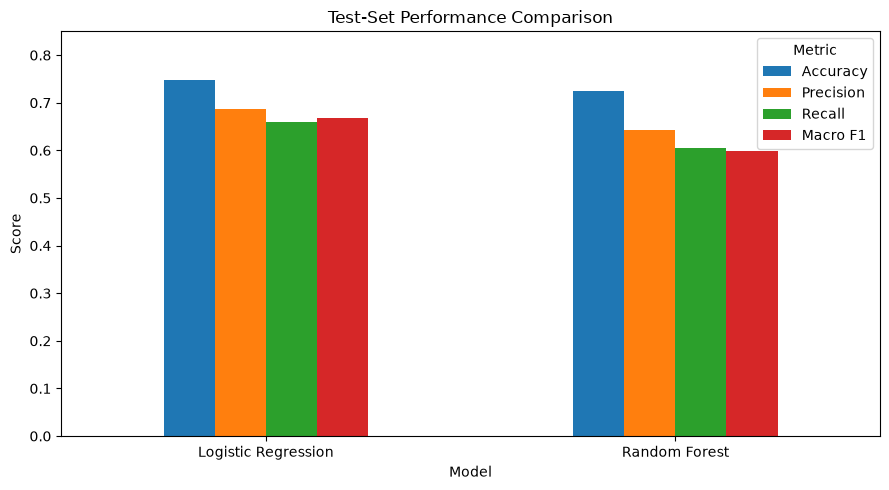

In [161]:
results.plot(
    kind='bar',
    figsize=(9, 5)
)

plt.title('Test-Set Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Score')
plt.ylim(0, 0.85)
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

### 6.3 Classification Reports

In [162]:
from sklearn.metrics import classification_report

print("Logistic Regression Classification Report:")
print(classification_report(y_test, logreg_pred))

print("\nRandom Forest Classification Report:")
print(classification_report(y_test, rf_pred))

Logistic Regression Classification Report:
              precision    recall  f1-score   support

     Dropout       0.79      0.75      0.77       284
    Enrolled       0.49      0.33      0.40       159
    Graduate       0.78      0.89      0.83       442

    accuracy                           0.75       885
   macro avg       0.69      0.66      0.67       885
weighted avg       0.73      0.75      0.74       885


Random Forest Classification Report:
              precision    recall  f1-score   support

     Dropout       0.74      0.73      0.73       284
    Enrolled       0.44      0.16      0.24       159
    Graduate       0.75      0.92      0.83       442

    accuracy                           0.72       885
   macro avg       0.64      0.61      0.60       885
weighted avg       0.69      0.72      0.69       885



### 6.4 Confusion Matrices

In [163]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

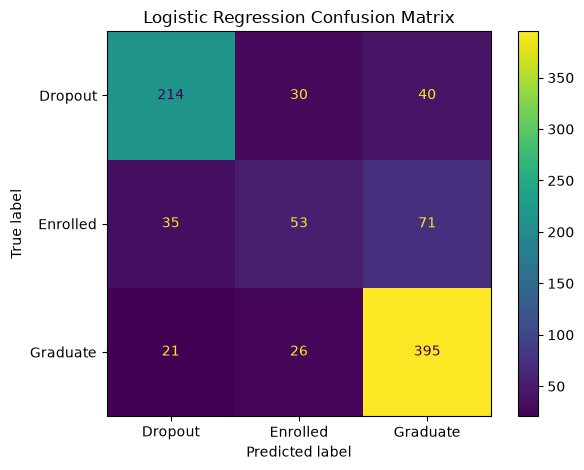

In [164]:
logreg_cm = confusion_matrix(
    y_test,
    logreg_pred,
    labels=best_logreg.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=logreg_cm,
    display_labels=best_logreg.classes_
)

disp.plot()
plt.title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()

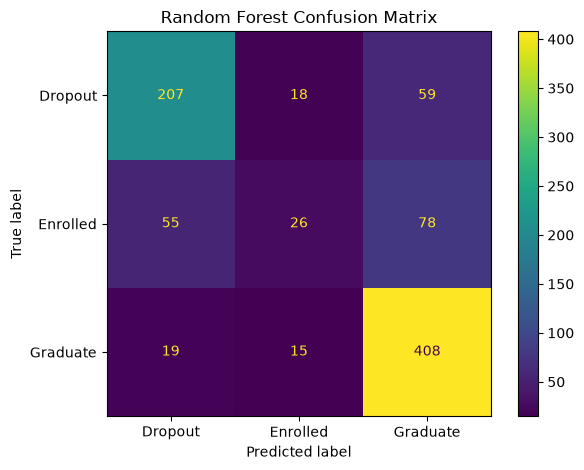

In [165]:
rf_cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=best_rf.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=best_rf.classes_
)

disp.plot()
plt.title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.show()

- Logistic Regression correctly classified 214 of 284 Dropout students,
  53 of 159 Enrolled students, and 395 of 442 Graduate students.

- Random Forest correctly classified 207 Dropout students,
  26 Enrolled students, and 408 Graduate students.

- Both models had difficulty identifying the Enrolled class.

- Random Forest identified more Graduate students correctly, but performed
  considerably worse for Enrolled students.

- Logistic Regression provided better balanced performance across the three
  outcome classes, which is consistent with its higher Macro F1 score.

## 7. Model Explainability

### 7.1 Permutation Feature Importance

In [166]:
from sklearn.inspection import permutation_importance

In [167]:
perm_importance = permutation_importance(
    best_logreg,
    X_test,
    y_test,
    scoring='f1_macro',
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [168]:
importance_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': perm_importance.importances_mean
})

importance_df = (
    importance_df
    .sort_values('Importance', ascending=False)
    .head(10)
)

importance_df

,Feature,Importance
24,Curricular units 1st sem (approved),0.241424
16,Tuition fees up to date,0.051484
22,Curricular units 1st sem (enrolled),0.044907
3,Course,0.039705
25,Curricular units 1st sem (grade),0.030641
27,Unemployment rate,0.028964
23,Curricular units 1st sem (evaluations),0.019946
21,Curricular units 1st sem (credited),0.018994
17,Gender,0.017860
8,Mother's qualification,0.016722


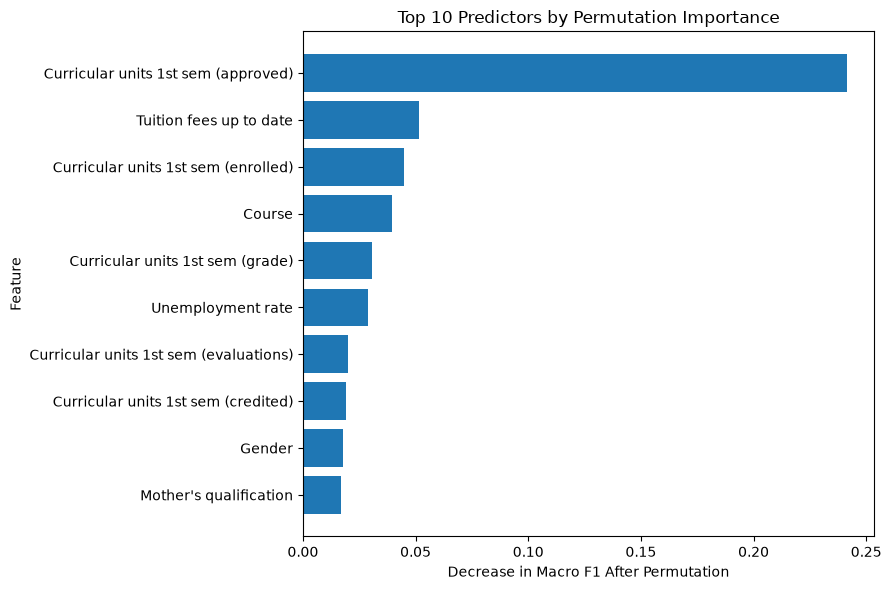

In [169]:
importance_plot = importance_df.sort_values('Importance')

plt.figure(figsize=(9, 6))
plt.barh(
    importance_plot['Feature'],
    importance_plot['Importance']
)

plt.title('Top 10 Predictors by Permutation Importance')
plt.xlabel('Decrease in Macro F1 After Permutation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## 8. Learning Curve Analysis

In [170]:
from sklearn.model_selection import learning_curve
import numpy as np

In [171]:
train_sizes, train_scores, validation_scores = learning_curve(
    best_logreg,
    X_train,
    y_train,
    cv=cv,
    scoring='f1_macro',
    train_sizes=np.linspace(0.2, 1.0, 5),
    n_jobs=-1
)

train_scores_mean = train_scores.mean(axis=1)
validation_scores_mean = validation_scores.mean(axis=1)

learning_curve_results = pd.DataFrame({
    'Training Size': train_sizes,
    'Training Macro F1': train_scores_mean,
    'Validation Macro F1': validation_scores_mean
})

learning_curve_results

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_scores_mean,
    marker='o',
    label='Training Macro F1'
)

plt.plot(
    train_sizes,
    validation_scores_mean,
    marker='o',
    label='Validation Macro F1'
)

plt.title('Learning Curve for Logistic Regression')
plt.xlabel('Training Set Size')
plt.ylabel('Macro F1')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Discussion

### 9.1 Model Selection and Strengths

- Logistic Regression was selected as the final model.
- Test Accuracy ≈ 0.748 and Macro F1 ≈ 0.667.
- Random Forest achieved Accuracy ≈ 0.724 and Macro F1 ≈ 0.599.
- Logistic Regression performed better across the overall test metrics.
- Its relatively simple structure also supports interpretability.

### 9.2 Limitations

- The Enrolled class was substantially harder to predict than Dropout or Graduate.
- The dataset has moderate class imbalance.
- The data comes from a particular higher-education context, so performance may
  not generalise directly to other institutions or student populations.
- The learning curve still shows a gap between training and validation performance.
- Predictive relationships should not be interpreted as causal relationships.

### 9.3 Explainability and Educational Implications

- Semester 1 approved curricular units was the strongest predictive feature.
- Tuition-fee status, Semester 1 enrolment, course and Semester 1 grade were also important.
- These are predictive associations rather than evidence that the variables cause
  dropout or graduation.
- The model could potentially support early identification of students who may
  benefit from additional academic support.

### 9.4 Fairness, Ethics and Privacy

- Some predictors, such as gender and socioeconomic or demographic variables,
  create fairness considerations.
- Historical educational data may contain existing inequalities or biases.
- Student data should be handled with appropriate privacy and access controls.
- Predictions should support human decision-making rather than automatically
  determine important educational decisions.
- Performance should be examined across relevant student groups before deployment.

### 9.5 Recommendations and Deployment

- Logistic Regression is the preferred model from this experiment.
- The model should be treated as a decision-support tool rather than an automated
  decision system.
- Particular caution is required for the Enrolled class because its recall was low.
- Before real-world deployment, the model should be validated on data from the
  institution where it will actually be used.
- Model performance and fairness should be monitored over time.
- Retraining may be necessary if student populations or educational conditions change.

## 10. Conclusion

- The project predicted three student outcomes at the end of Semester 1:
  Dropout, Enrolled and Graduate.
- Logistic Regression and Random Forest were compared.
- Logistic Regression was selected because it achieved the stronger overall
  test performance, including Macro F1 ≈ 0.667.
- The Enrolled class remained the main classification challenge.
- The model may support educational decision-making, but predictions should
  not replace human judgement.